# MetaLore — Quick Demo

In [1]:
import sys
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import small_config

print('MetaLore imported successfully!')

MetaLore imported successfully!


## Create & Reset Environment

In [2]:
env = SingleCellEnv(config=small_config())
obs, info = env.reset()

print(f'Base Stations : {env.num_bs}')
print(f'UEs           : {env.num_ues}')
print(f'Sensors       : {env.num_sensors}')
print(f'Area          : {env.width} x {env.height} m')
print(f'Max Steps     : {env.EP_MAX_TIME}')
print(f'Action Space  : {env.action_space}')
print(f'Obs Space     : {env.observation_space}')
print(f'Initial obs   : {obs}')

Base Stations : 1
UEs           : 5
Sensors       : 8
Area          : 200.0 x 200.0 m
Max Steps     : 100
Action Space  : Box(0.0, 1.0, (2,), float32)
Obs Space     : Box(0.0, 10000.0, (2,), float32)
Initial obs   : [0. 0.]


## Run Episode with Rendering

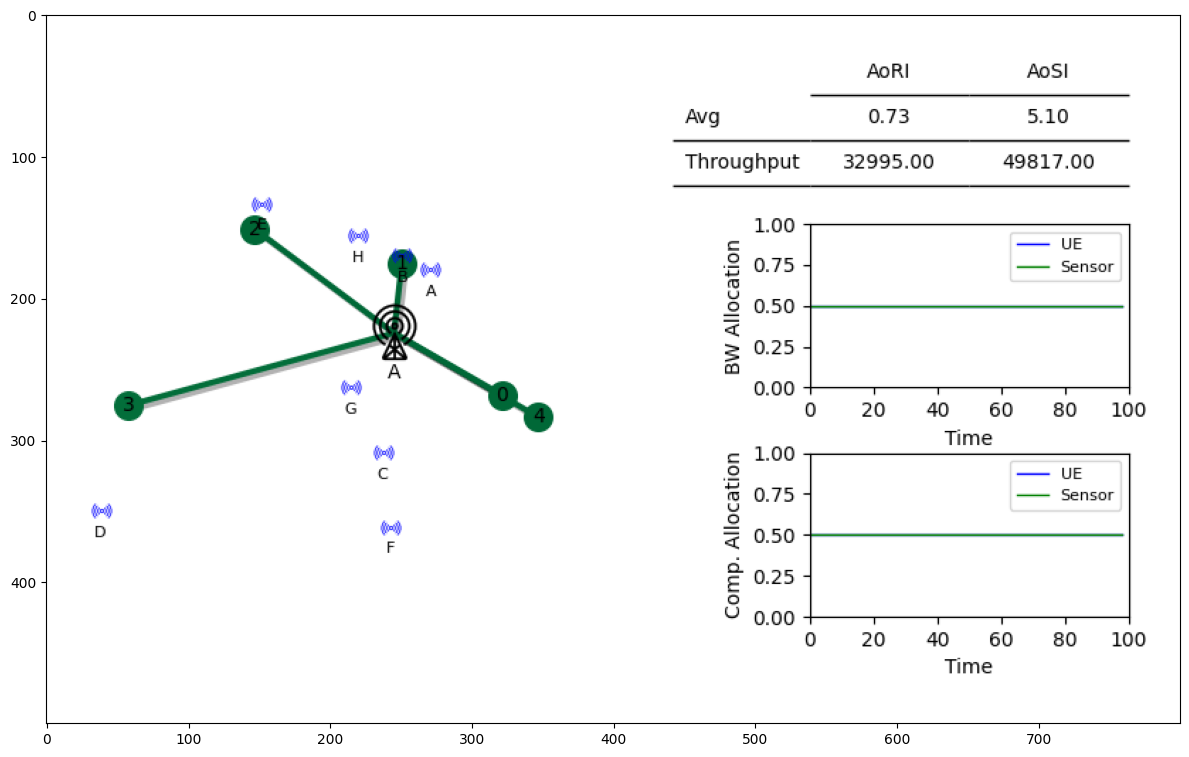

Episode ended at step 100

Steps completed : 100
Total reward    : 2285.1397


In [3]:
# Run a full episode with random actions
N_STEPS =  100

rewards = []
for step in range(N_STEPS):
    #action = env.action_space.sample()   # random policy
    action = [0.5, 0.5]                   # fixed equal-split policy
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break
    
    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

print()
print(f"Steps completed : {len(rewards)}")
print(f"Total reward    : {sum(rewards):.4f}")

## Job Log (completed jobs)

In [4]:
import pandas as pd
from IPython.display import display

job_df = env.job_tracker.to_dataframe()
print(f'Completed jobs: {len(job_df)}')
display(job_df)

Completed jobs: 1051


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,3,0,SENSOR,76.0,7.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,4,1,SENSOR,51.0,9.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
2,5,2,SENSOR,71.0,8.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
3,7,4,SENSOR,54.0,6.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
4,8,5,SENSOR,60.0,4.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,978,5,SENSOR,52.0,7.0,85,95,95,99,99,10,0,4,0,NaN,NaN,NaN,14,NaN
1047,1088,6,SENSOR,68.0,6.0,95,95,95,99,99,0,0,4,0,NaN,NaN,NaN,4,NaN
1048,1089,7,SENSOR,60.0,6.0,95,95,95,99,99,0,0,4,0,NaN,NaN,NaN,4,NaN
1049,1091,0,SENSOR,82.0,7.0,96,96,96,99,99,0,0,3,0,NaN,NaN,NaN,3,NaN


## All Generated Jobs (monitor)

In [5]:
monitor_df = env.monitor.dataframe()
print(f'All generated jobs: {len(monitor_df)}')
display(monitor_df)

All generated jobs: 1132


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,is_transmitted,is_processed,tx_start_at,tx_end_at,...,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,0,1,UE,106.0,6.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1,3,UE,102.0,10.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,4.0,0.0,1.0,1.0,0.0
2,2,4,UE,94.0,7.0,0,True,True,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,5.0,0.0,1.0,1.0,0.0
3,3,0,SENSOR,76.0,7.0,0,True,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN
4,4,1,SENSOR,51.0,9.0,0,True,True,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1127,1127,3,SENSOR,68.0,8.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1128,1128,4,SENSOR,75.0,6.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1129,1129,5,SENSOR,67.0,9.0,99,False,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1130,1130,6,SENSOR,68.0,8.0,99,True,False,99.0,99.0,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## AoI Summary (UE jobs only)

In [6]:
ue_df = job_df[job_df['entity_type'] == 'UE']

for col, label in [('aori', 'AoRI'), ('aosi', 'AoSI'), ('aoi', 'AoI')]:
    s = ue_df[col].dropna()
    if not s.empty:
        print(f'{label:5s}  mean={s.mean():.2f}  max={s.max():.0f}  min={s.min():.0f}')

AoRI   mean=0.73  max=2  min=0
AoSI   mean=5.09  max=36  min=0
AoI    mean=5.82  max=37  min=1
